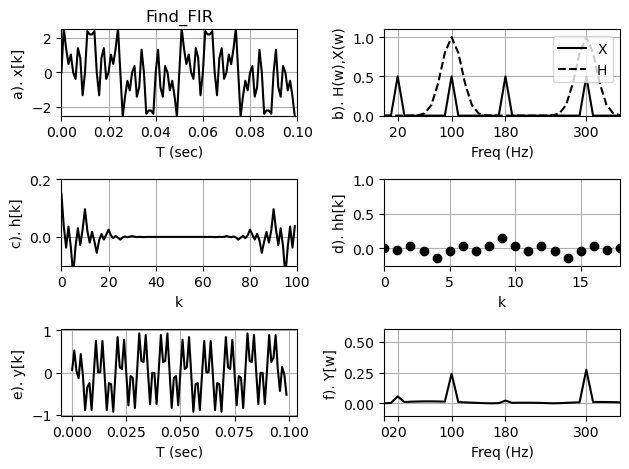

In [19]:
""" Problem 9.4.3 """

import matplotlib.pyplot as plt
import numpy as np
from scipy import signal as sig
from math import pi, exp, cos, sin, log, sqrt

NN = 100
N2 = int(NN/2)
x = np.zeros(NN)
y = np.zeros(NN)

dt = .001
TT = np.linspace(0,dt*(NN-1),NN)
DF = 1/(dt*NN)
FF = np.linspace(0,DF*(NN-1),NN)

""" Create the time-domain input """

f1 = 20
f2 = 100
f3 = 180
f4 = 300
freq1 = 2*pi*f1
freq2 = 2*pi*f2
freq3 = 2*pi*f3
freq4 = 2*pi*f4

x = np.sin(freq1*TT) + 1*np.sin(freq2*TT) + 1*np.sin(freq3*TT) + 1*np.sin(freq4*TT)

plt.subplot(321)
plt.plot(TT,x,'k')
plt.axis([0,NN*dt,-2.5,2.5])
#plt.text(5,-15,'$\phi$ = {}'.format(round(14,3)),fontsize=12)
plt.title('Find_FIR')
plt.ylabel('a). x[k]')
plt.xlabel('T (sec)')
plt.grid()

X = (1/NN)*np.fft.fft(x)

""" Create the filter """
H = np.zeros(NN)

""" Rectangular Low pass """
# for n in range(8):
    # H[n] = 1

""" Low pass """
# for n in range(4):
#     H[n] = 1
# for n in range(4,16):
#     H[n] = exp(-.5*((n-4)/4)**2)

""" Band pass """
for n in range(N2):
    H[n] = exp(-.5*((n-10)/1.5)**2) + exp(-.5*((n-30)/1.5)**2)
    #(n-[shift_right])/[width_of_curve]

""" High pass """
# #range(#) should equal for both
# for n in range(30): #Where the curve of the filter begins
#     H[n] = exp(-.5*((n-30)/4)**2)
# for n in range(30,N2+2): #Where the plateau at y=1 begins
#     H[n] = 1

""" Reflect the positive frequencies to the right side """
for n in range(1,N2-1):
    H[NN-n] = H[n]

Y = H*X

plt.subplot(322)
plt.plot(FF,abs(X),'k',label='X')
plt.plot(FF,H,'k--',label='H')
plt.legend(loc='upper right')
plt.ylabel('b). H(w),X(w)')
plt.xlabel('Freq (Hz)')
plt.grid()
#plt.savefig('f.png')
plt.axis([0,350,0,1.1]) #[0,500,0,1.1] to include the reflection
plt.xticks([20,100,180,300])

h = np.fft.ifft(H)

plt.subplot(323)
plt.plot(h.real,'k')
plt.xlabel('k')
plt.ylabel('c). h[k]')
plt.grid()
plt.axis([0,NN,-.1,.2])

M = 9 #hh will have 2*M + 1 points
#if final plot has too many points, increase M to 9
hh = np.zeros(NN)

""" Move the filter to the left side """
for n in range(M):
    hh[n+M] = h[n].real
    hh[M-n] = hh[M+n]

plt.subplot(324)
plt.plot(hh,'ok')
plt.axis([0 ,2*M,-.25,1]) #increase y axis to 1 if using HPF
plt.xlabel('k')
plt.ylabel('d). hh[k]')
plt.grid()

""" Convolve hh and x """

yy=np.convolve(hh,x)

y = np.zeros(NN)
for n in range(NN):
    y[n] = yy[n+M]

plt.subplot(325)
plt.plot(TT,y,'k')
4
plt.ylabel('e). y[k]')
plt.xlabel('T (sec)')
plt.grid()

Y = (1/NN)*np.fft.fft(y)

plt.subplot(326)
plt.plot(FF,abs(Y),'k')
plt.ylabel('f). Y[w]')
plt.xlabel('Freq (Hz)')
plt.grid()
plt.xticks([0,20,100,180,300])
plt.axis([0,350,-.1,.6])
#plt.savefig('f.png',dpi=300)
plt.tight_layout()
plt.show()